In [ ]:
!pip install -q google-genai pillow

In [ ]:

from google import genai

API_KEY = "AQ.Ab8RN6J_eoe5K5gocgGTkdKxri_egwGO3HlOJzQmzaTJa9TnuQ"

client = genai.Client(api_key=API_KEY)

print("Gemini AI connected successfully!")

Gemini AI connected successfully!


Saving images (64).jpeg to images (64).jpeg
Image uploaded successfully: images (64).jpeg


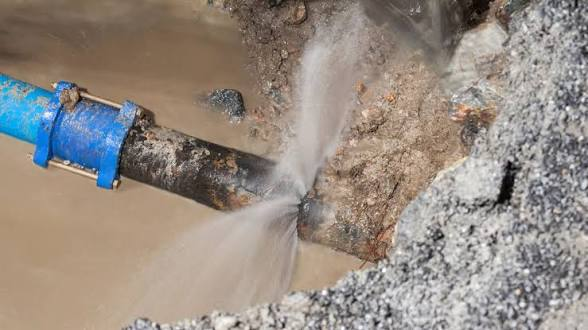

In [ ]:
from google.colab import files
from PIL import Image
import io

# Upload an image
uploaded = files.upload()

# Get uploaded image name
image_name = list(uploaded.keys())[0]

# Open image
img = Image.open(io.BytesIO(uploaded[image_name]))

print("Image uploaded successfully:", image_name)

# Display image
display(img)

In [ ]:
prompt = """
Analyze this image for a civic problem.

Classify it into ONLY one of these categories:
1. Pothole
2. Garbage
3. Broken Streetlight
4. Water Leakage
5. Damaged Road
6. Other

Also provide:
- Confidence percentage from 0 to 100
- Priority: Low, Medium, or High
- A short description of the problem

Return ONLY valid JSON in this format:

{
  "category": "Pothole",
  "confidence": 94,
  "priority": "High",
  "description": "Short description here"
}
"""

response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=[prompt, img]
)

print(response.text)

In [ ]:
import json
import re

# Remove ```json and ``` if Gemini adds them
clean_response = response.text.strip()

clean_response = re.sub(r"^```json\s*", "", clean_response)
clean_response = re.sub(r"^```\s*", "", clean_response)
clean_response = re.sub(r"\s*```$", "", clean_response)

# Convert AI response into Python dictionary
result = json.loads(clean_response)

print("Category:", result["category"])
print("Confidence:", result["confidence"], "%")
print("Priority:", result["priority"])
print("Description:", result["description"])

Category: Garbage
Confidence: 98 %
Priority: Medium
Description: Accumulation of uncollected trash bags and plastic litter dumped on the side of the street.
